In [4]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
df1_columns_to_use = [
    'Months to Last Follow-up',
    'Date of Injury',
    'Time of Injury',
    'Date to OR at MEE',
    'Time to OR at MEE',
    'Time from Injury to OR',
    'Date of presentation to MEE',
    'Day of Week of Presentation',
    'Time of presentation to MEE',
    'Eye',
    'Post-op VA at last follow-up',
    'Date of Last Follow-up',
    'Age at time of injury',
    'Sex',
    'Race',
    'Ethnicity',
    'Mechanism (Rupture v Perforation v Penetration)',
    'Mechanism',
    'Patient location during Injury',
    'Presenting VA',
    'APD (Y/N)',
    'IOFB (Y/N)',
    'Zone I',
    'Zone II',
    'Zone III',
    'Maximal Zone of Injury',
    'Uveal Prolapse (Y/N)',
    'Lensectomy (Y/N)',
    'Post-op Sight-improving Surgery (Y/N)',
    'Endophthalmitis (Y/N)',
    'Patient Profession',
    'Insurance Type',
    'State',
    'Pre-globe Ocular Surgeries in traumatized eye (if known)',
    'Pre-globe Ocular Comorbidities in truamatized eye (if known)',
    'Retinal Detachment (Y/N)',
    'Choroidal Hemorrhage (Y/N)',
    'Scleral Buckle (Y/N)',
    'PPV (Y/N)',
    'Vitreous Hemorrhage (Y/N)',
    'Lens Capsular Violation (Y/N)',
    'Lens taken primarily (Y/N)',
    'Lens taken secondarily (Y/N)',
    'Pseudo/Aphakic prior or due to trauma (Y/N)',
    'Self-sealed (Y/N)',
    'Disinsertion of Rectus (Y/N)',
    'PK (Y/N)',
    'Enucleation (Y/N)',
    'Date of Enucleation',
    'Primary or Secondary Enucleation',
    'Enucleation or Evisceration',
    'Indication for Enucleation',
    'Additional surgeries necessary',
    'Next Additional surgery necessary ',
    'Date of next surgery'    
]

df = pd.read_csv('Original Combined Dataset 2012-2022.csv', usecols= df1_columns_to_use) 

#Cleaning Data Start ------------------

#dropping patients with missing presenting VA, post op VA, endophthalmitis, time to OR
df = df.dropna(subset=['Post-op VA at last follow-up'])
df = df.dropna(subset=['Presenting VA'])
df = df.dropna(subset=['Endophthalmitis (Y/N)'])
df = df.dropna(subset=['Time to OR at MEE'])

#converting different spellings of rupture, perforation, penetration -> rup, pen, perf
#df['Mechanism (Rupture v Perforation v Penetration)'].describe(include='all')
df['Mechanism (Rupture v Perforation v Penetration)'] = df['Mechanism (Rupture v Perforation v Penetration)'].str.replace(' ', '')
df['Mechanism (Rupture v Perforation v Penetration)'].replace(to_replace=dict(Rupture = 'rup'), inplace=True)
df['Mechanism (Rupture v Perforation v Penetration)'].replace(to_replace=dict(rupture = 'rup'), inplace=True)
df['Mechanism (Rupture v Perforation v Penetration)'].replace(to_replace=dict(Penetration = 'pen'), inplace=True)
df['Mechanism (Rupture v Perforation v Penetration)'].replace(to_replace=dict(penetration = 'pen'), inplace=True)
df['Mechanism (Rupture v Perforation v Penetration)'].replace(to_replace=dict(perforation = 'perf'), inplace=True)
df['Mechanism (Rupture v Perforation v Penetration)'].replace(to_replace=dict(Perforation = 'perf'), inplace=True)
rup = ['rup']
pen = ['pen']
perf = ['perf']

#creating columns for rupture, penetration, perforation as binary variables
condition_rup = list(map(df['Mechanism (Rupture v Perforation v Penetration)'].str.contains, rup))
condition_pen = list(map(df['Mechanism (Rupture v Perforation v Penetration)'].str.contains, pen))
condition_perf = list(map(df['Mechanism (Rupture v Perforation v Penetration)'].str.contains, perf))
df['Rupture'] = np.select(condition_rup, 'Y', 'N')
df['Penetration'] = np.select(condition_pen, 'Y', 'N')
df['Perforation'] = np.select(condition_perf, 'Y', 'N')


#deleting patients with non numerical presenting VA
df = df[df['Presenting VA'].str.contains("F/F") == False]
df = df[df['Presenting VA'].str.contains("unable") == False]
df = df[df['Presenting VA'].str.contains("20/30") == False]
df = df[df['Presenting VA'].str.contains("20/40") == False]

#converting presenting VA to float
df['Presenting VA'] = df['Presenting VA'].astype(float)

#assuming no value stored for retinal detachment = no retinal detachment
df['Retinal Detachment (Y/N)'] = df['Retinal Detachment (Y/N)'].fillna('N')


#converting date to year 
df['Year to OR at MEE'] = 2023 - pd.DatetimeIndex(df['Date to OR at MEE']).year

#Transforing strings to numbers 
Le = LabelEncoder()
df['Sex'] = Le.fit_transform(df['Sex'])
df['Day of Week of Presentation'] = Le.fit_transform(df['Day of Week of Presentation'])
df['Eye'] = Le.fit_transform(df['Eye'])
df['Rupture'] = Le.fit_transform(df['Rupture'])
df['Penetration'] = Le.fit_transform(df['Penetration'])
df['Perforation'] = Le.fit_transform(df['Perforation'])
df['Retinal Detachment (Y/N)'] = Le.fit_transform(df['Retinal Detachment (Y/N)'])
df['APD (Y/N)'] = Le.fit_transform(df['APD (Y/N)'])
df['Endophthalmitis (Y/N)'] = Le.fit_transform(df['Endophthalmitis (Y/N)'])
df['IOFB (Y/N)'] = Le.fit_transform(df['IOFB (Y/N)'])
df['Zone I'] = Le.fit_transform(df['Zone I'])
df['Zone II'] = Le.fit_transform(df['Zone II'])
df['Zone III'] = Le.fit_transform(df['Zone III'])
df['Lensectomy (Y/N)'] = Le.fit_transform(df['Lensectomy (Y/N)'])
df['Uveal Prolapse (Y/N)'] = Le.fit_transform(df['Uveal Prolapse (Y/N)'])




#Visual acuity values count fingers (CF), hand motion (HM), light perception (LP), and no light perception (NLP) were converted to 2.0, 2.4, 2.7, and 3.0, respectively
# (low vision key in spreadsheet) -> logMAR equivilant
#CF = 2,000 -> 2.0
#HM = 6,000 -> 2.4
#LP = 10,000 -> 2.7
#NLP = 100,000 -> 3.0
#PMID: 28299240
#PMID: 18766368
#converting low VA to logMAR equivilant
df['Presenting VA'] = df['Presenting VA'].replace([100000], 3)
df['Presenting VA'] = df['Presenting VA'].replace([10000], 2.7)
df['Presenting VA'] = df['Presenting VA'].replace([6000], 2.4)
df['Presenting VA'] = df['Presenting VA'].replace([2000], 2)

df['Post-op VA at last follow-up'] = df['Post-op VA at last follow-up'].replace([100000], 3)
df['Post-op VA at last follow-up'] = df['Post-op VA at last follow-up'].replace([10000], 2.7)
df['Post-op VA at last follow-up'] = df['Post-op VA at last follow-up'].replace([6000], 2.4)
df['Post-op VA at last follow-up'] = df['Post-op VA at last follow-up'].replace([2000], 2)
#df.to_csv('out.csv')

#Converting Snellen VA to logMAR
df.loc[df['Presenting VA'] >5, "Presenting VA"] = np.log10((df['Presenting VA']/20))
df.loc[df['Post-op VA at last follow-up'] >5, "Post-op VA at last follow-up"] = np.log10((df['Post-op VA at last follow-up']/20))

#creating specific columns for race
White = []
Black = []
Asian = []
Indian = []
Hawaiian = []

for value in df['Race']:
    if value == "White":
        White.append(1)
    else:
        White.append(0)
        
for value in df['Race']:
    if value == "Black":
        Black.append(1)
    else:
        Black.append(0)   
        
for value in df['Race']:
    if value == "Asian":
        Asian.append(1)
    else:
        Asian.append(0) 
        
for value in df['Race']:
    if value == "American Indian or Alaskan Native":
        Indian.append(1)
    else:
        Indian.append(0) 
        
for value in df['Race']:
    if value == "Native Hawaiian Or Other Pacific Islander":
        Hawaiian.append(1)
    else:
        Hawaiian.append(0) 
        
df['White'] = White
df['Black'] = Black
df['Asian'] = Asian
df['Indian'] = Indian
df['Hawaiian'] = Hawaiian

#creating specific column for Ethnicity
Hispanic = []
for value in df['Ethnicity']:
    if value == "Hispanic":
        Hispanic.append(1)
    else:
        Hispanic.append(0)
df['Hispanic'] = Hispanic

#creating specific columns for mechanism

Fall = []
Projectile = []
Nail = []
Blunt = []
Glass = []
Assault = []
Wood = []
MVC = []
Wire = []
Knife = []
Metal = []

for value in df['Mechanism']:
    if value == "fall":
        Fall.append(1)
    else:
        Fall.append(0)
for value in df['Mechanism']:
    if value == "Projectile":
        Projectile.append(1)
    else:
        Projectile.append(0)        
for value in df['Mechanism']:
    if value == "Nail":
        Nail.append(1)
    else:
        Nail.append(0)           
for value in df['Mechanism']:
    if value == "Blunt":
        Blunt.append(1)
    else:
        Blunt.append(0)            
for value in df['Mechanism']:
    if value == "Glass":
        Glass.append(1)
    else:
        Glass.append(0)        
for value in df['Mechanism']:
    if value == "Assault":
        Assault.append(1)
    else:
        Assault.append(0)
for value in df['Mechanism']:
    if value == "Wood":
        Wood.append(1)
    else:
        Wood.append(0)         
for value in df['Mechanism']:
    if value == "MVC":
        MVC.append(1)
    else:
        MVC.append(0)          
for value in df['Mechanism']:
    if value == "Wire":
        Wire.append(1)
    else:
        Wire.append(0)           
for value in df['Mechanism']:
    if value == "Knife/Blade":
        Knife.append(1)
    else:
        Knife.append(0)         
for value in df['Mechanism']:
    if value == "Metal":
        Metal.append(1)
    else:
        Metal.append(0)          
        
df['Fall'] = Fall
df['Projectile'] = Projectile 
df['Nail'] = Nail
df['Blunt'] = Blunt 
df['Glass'] = Glass 
df['Assault'] = Assault 
df['Wood'] = Wood
df['MVC'] = MVC 
df['Wire'] = Wire 
df['Knife'] = Knife 
df['Metal'] = Metal 


#converting time from presentation to OR into minutes
df1 = df['Time to OR at MEE'].str.split(':', n=1).str[0]
df2 = df['Time to OR at MEE'].str.split(':', n=1).str[1]

df1 = df1.astype(float)
df2 = df2.replace(np.nan, 0)
df2 = df2.fillna(0)
df3 = df2.str[0] + df2.str[1]
df3 = df3.fillna(0)
df1.to_csv('df1.csv')
df3.to_csv('df3.csv')
df.to_csv('df.csv')
df1 = df1.astype(float)
df3 = df3.astype(float)
df['Time to OR (minutes)'] = df1*60 +df3

# Cleaning Data End ---------------

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
lm = LinearRegression()
rf = RandomForestRegressor()
dt = DecisionTreeRegressor()
svr = make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2))
mlp = MLPRegressor()
X = df[[
    
    #continuous inputs
    'Age at time of injury', 
    'Time to OR (minutes)',
    'Year to OR at MEE',
    'Presenting VA',
    #categorical inputs
    
    'Sex', 
    #'Eye',     
    'Rupture', 
    'Penetration', 
    'Perforation', 
    'Endophthalmitis (Y/N)', 
    'Retinal Detachment (Y/N)', 
    'APD (Y/N)', 
    'IOFB (Y/N)',
    'Zone I',
    'Zone II',
    'Zone III',
    'Lensectomy (Y/N)',
    'Uveal Prolapse (Y/N)',
    
    #comment each individually
    'White',
    'Black',
    'Asian',
    'Indian',
    'Hawaiian',
    'Hispanic',
    
    #
    'Fall',
    'Projectile',
    'Nail',
    'Blunt',
    'Glass',
    'Assault',
    'Wood',
    'MVC',
    'Wire',
    'Knife',
    'Metal'
    
    #
           
       ]]
y = df['Post-op VA at last follow-up']


#creating hold-out partition to test best performing model (20% of original data)
X_train, X_test_holdout, y_train, y_test_holdout = train_test_split(X, y, test_size=0.2, random_state=100)

In [6]:
from sklearn.model_selection import GridSearchCV
model_params = {
    'svr': {
        'model': SVR(),
        'params' : {
            'C': [1],
            'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
        }  
    }, 
    'decision tree': {
        'model': DecisionTreeRegressor(),
        'params' : {
            'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
            
        }  
    },
    'mlp neural network': {
        'model': MLPRegressor(),
        'params' : {
            'activation': ['relu', 'identity', 'logistic', 'tanh'],
            'solver': ['adam'],
            'max_iter': [750]
            
        }  
    },
    
    'random_forest': {
        'model': RandomForestRegressor(),
        'params' : {
            'n_estimators': [int(x) for x in np.linspace(start = 100, stop = 1000, num = 5)]
        }
    },
    'linear_regression' : {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': ['false', 'true'],
            'copy_X': ['false', 'true'],
            'positive': ['false', 'true']
        }
    }
}
scores = []

for model_name, mp in model_params.items():
    clf =  GridSearchCV(mp['model'], mp['params'], scoring='neg_mean_absolute_error', cv=10, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    
results = pd.DataFrame(scores,columns=['model','best_score','best_params'])
results

,model,best_score,best_params
0,svr,-1.026582,"{'C': 1, 'kernel': 'poly'}"
1,decision tree,-0.705286,{'criterion': 'absolute_error'}
2,mlp neural network,-0.706839,"{'activation': 'identity', 'max_iter': 750, 's..."
3,random_forest,-0.559358,{'n_estimators': 550}
4,linear_regression,-0.667889,"{'copy_X': 'false', 'fit_intercept': 'false', ..."


In [440]:
#re-training best performing model (random forest) and testing on 20% holdout group
from sklearn import metrics
rf = RandomForestRegressor(n_estimators = 1000).fit(X_train, y_train)
regressor_prediction = rf.predict(X_test_holdout)
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_holdout, regressor_prediction))

Mean Absolute Error: 0.5455388529774827


In [441]:
#converting predicted and testing final VA into categorical buckets
y_pred = pd.DataFrame(regressor_prediction, columns = ['continuous_prediction'])
y_pred['Predicted VA (classified)'] = pd.cut(y_pred['continuous_prediction'], bins=[-2,0.3011,1,2.0001,2.9,6], labels=[1,2,3,4,5])
#getting around weird error?
y_test_holdout.to_csv('y_test.csv')
y_true = pd.read_csv('y_test.csv', usecols= ['Post-op VA at last follow-up']) 
y_true['Actual Final VA (classified)'] = pd.cut(y_true['Post-op VA at last follow-up'], bins=[-2,0.3011,1,2.0001,2.9,6], labels=[1,2,3,4,5])

#calculating OTS contribuition from presenting VA
ots_va = []
for value in X_test_holdout['Presenting VA']:
    if value <= 0.3011:
        ots_va.append(100)
    elif value <= 1 and value > 0.3011:
        ots_va.append(90)
    elif value <= 2 and value > 1:
        ots_va.append(80)
    elif value <= 2.9  and value > 2:
        ots_va.append(70)
    else:
        ots_va.append(60)
X_test_holdout['OTS VA component'] = ots_va

#calculating total OTS score
X_test_holdout['OTS'] = (
    X_test_holdout['OTS VA component'] 
    - 23*X_test_holdout['Rupture'] 
    - 17*X_test_holdout['Endophthalmitis (Y/N)'] 
    - 14*X_test_holdout['Perforation'] 
    - 11*X_test_holdout['Retinal Detachment (Y/N)'] 
    - 10*X_test_holdout['APD (Y/N)']
) 
#calculating predicted VA category based on OTS
ots_prediction = []
for value in X_test_holdout['OTS']:
    if value <= 44:
        ots_prediction.append(5)
    elif value <= 65 and value > 44:
        ots_prediction.append(5)
    elif value <= 80 and value > 65:
        ots_prediction.append(1)
    elif value <= 91  and value >80 :
        ots_prediction.append(1)
    else:
        ots_prediction.append(1)
        
X_test_holdout['OTS predicted category']  = ots_prediction      
 
#calculating accuracy to compare model to OTS    
from sklearn.metrics import accuracy_score
ground_truth = y_true['Actual Final VA (classified)'].values
OTS_predictions = X_test_holdout['OTS predicted category'].values
regression_predictions = y_pred['Predicted VA (classified)']

OTS_accuracy = accuracy_score(ground_truth, OTS_predictions)
regression_accuracy = accuracy_score(ground_truth, regression_predictions)     

In [442]:
print(regression_accuracy)

0.4644808743169399


In [443]:
print(OTS_accuracy)

0.5081967213114754


Text(69.0, 0.5, 'OTS Prediction')

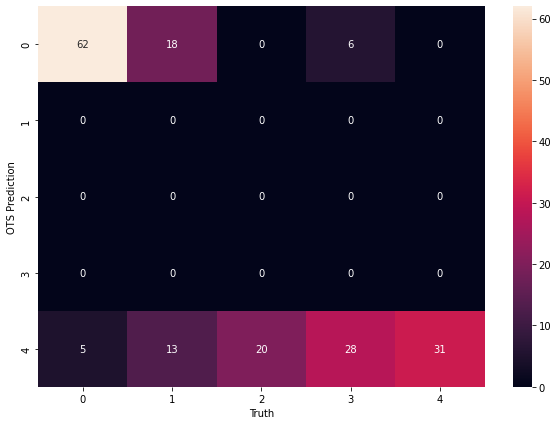

In [444]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(X_test_holdout['OTS predicted category'], y_true['Actual Final VA (classified)'])


#print(cm)
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot = True)
plt.xlabel('Truth')
plt.ylabel('OTS Prediction')

Text(69.0, 0.5, 'ML Prediction')

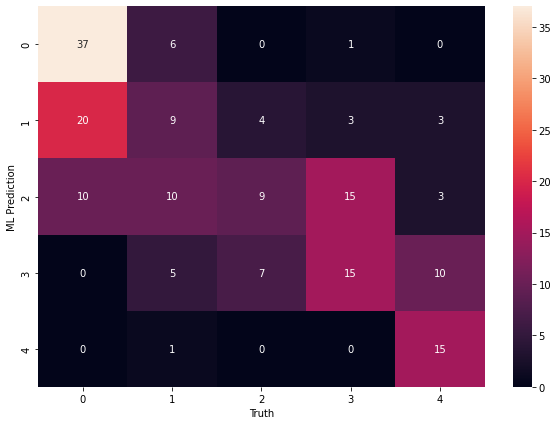

In [445]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_pred['Predicted VA (classified)'], y_true['Actual Final VA (classified)'])

#print(cm)
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot = True)
plt.xlabel('Truth')
plt.ylabel('ML Prediction')